### `Scanpy` Usage Example

Author: Phoebe Kuang

Editing History:

- 6/15/2026: Initial Draft

In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# 0. Configuration

sc.settings.verbosity = 3 
sc.set_figure_params(dpi=150, facecolor='white')

In [3]:
# 1. Data Loading

adata = sc.datasets.pbmc3k() # N=2700 cells, G=32738 genes
adata.var_names_make_unique() # Ensure gene names are unique
print(f"Raw Matrix Shape: {adata.X.shape[0]} cells, {adata.X.shape[1]} genes")

Raw Matrix Shape: 2700 cells, 32738 genes


In [4]:
# 2. Quality Control (QC) & Filtering

# Identify mitochondrial genes (they start with 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-')
# Calculate QC metrics and append them to adata.obs and adata.var
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

# Filter out dead cells (too many mitochondrial genes) and empty droplets (too few genes)
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs.pct_counts_mt < 5, :]

print(f"Post-QC Matrix Shape: {adata.X.shape[0]} cells, {adata.X.shape[1]} genes")

filtered out 19024 genes that are detected in less than 3 cells
Post-QC Matrix Shape: 2643 cells, 13714 genes


In [5]:
# 3. Normalization & Variance Stabilization

# Save the raw integer counts before we mutate the main matrix
adata.layers["counts"] = adata.X.copy()

# Library size normalization (scale all cells to sum to 10,000)
sc.pp.normalize_total(adata, target_sum=1e4)
# Log1p transformation: Y = ln(X + 1)
sc.pp.log1p(adata)

normalizing counts per cell
    finished (0:00:02)


In [6]:
# 4. Highly Variable Genes (HVG) Selection

sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)

# Save the full, normalized matrix (all genes) into the .raw attribute before slicing
adata.raw = adata 

# Filter the matrix in memory to only keep the highly variable genes
adata = adata[:, adata.var.highly_variable]

extracting highly variable genes
    finished (0:00:01)
--> added
    'highly_variable', boolean vector (adata.var)
    'means', float vector (adata.var)
    'dispersions', float vector (adata.var)
    'dispersions_norm', float vector (adata.var)


In [7]:
#  5. Dimensionality Reduction (PCA)

# Scale the data to unit variance and zero mean before PCA
sc.pp.scale(adata, max_value=10)
# Run PCA to condense genes down to the top 50 Principal Components
sc.tl.pca(adata, svd_solver='arpack')

computing PCA
    with n_comps=50
    finished (0:00:01)


In [8]:
# 6. Neighborhood Graph & Clustering

# Build a mathematical graph connecting each cell to its closest neighbors in PCA space
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
# Run the Leiden algorithm to find distinct communities (clusters) in the graph
sc.tl.leiden(adata, resolution=0.5)
# Calculate the 2D UMAP embedding for visualization
sc.tl.umap(adata)

computing neighbors
    using 'X_pca' with n_pcs = 40
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:16)
running Leiden clustering
    finished: found 6 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:06)


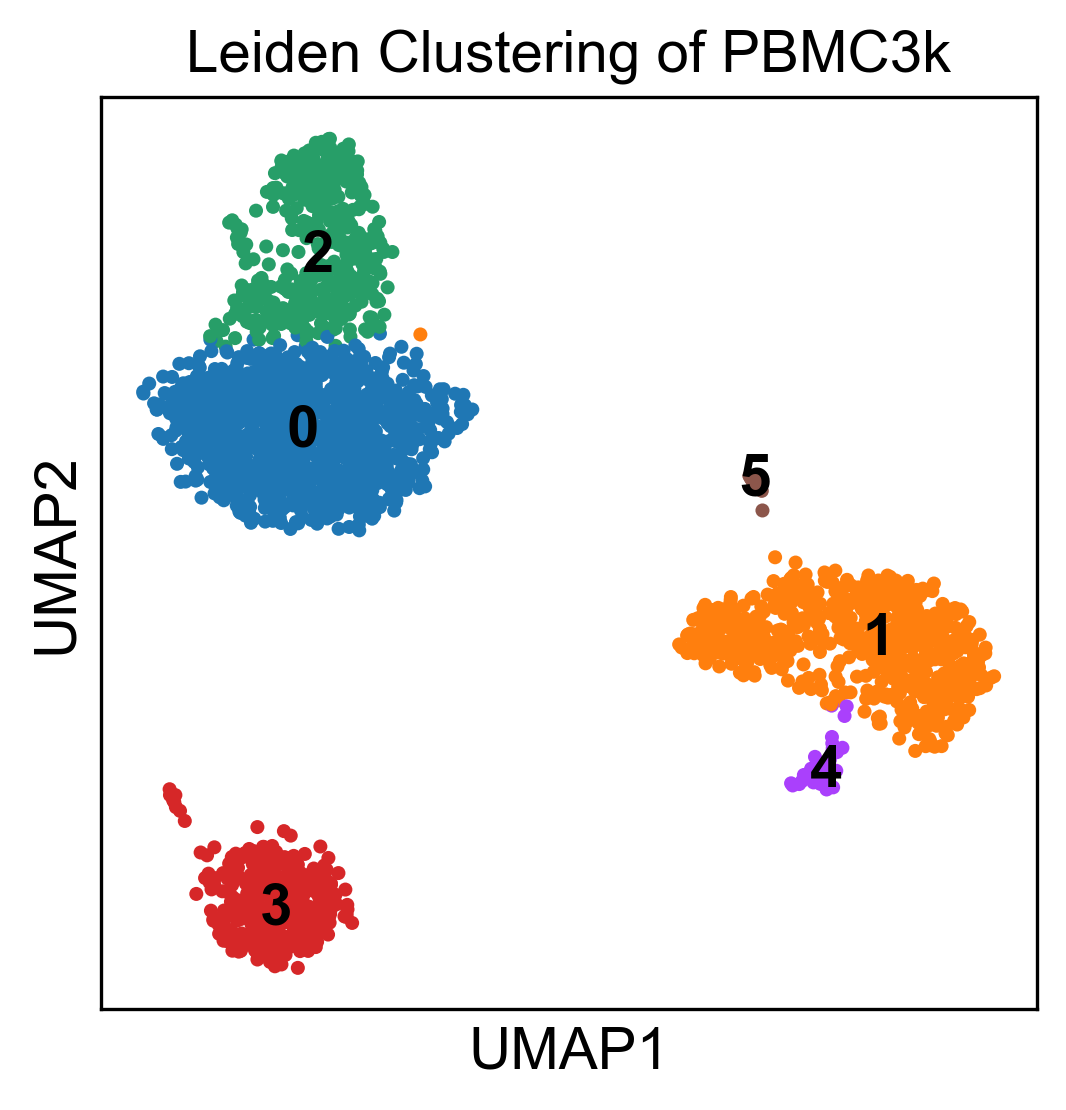

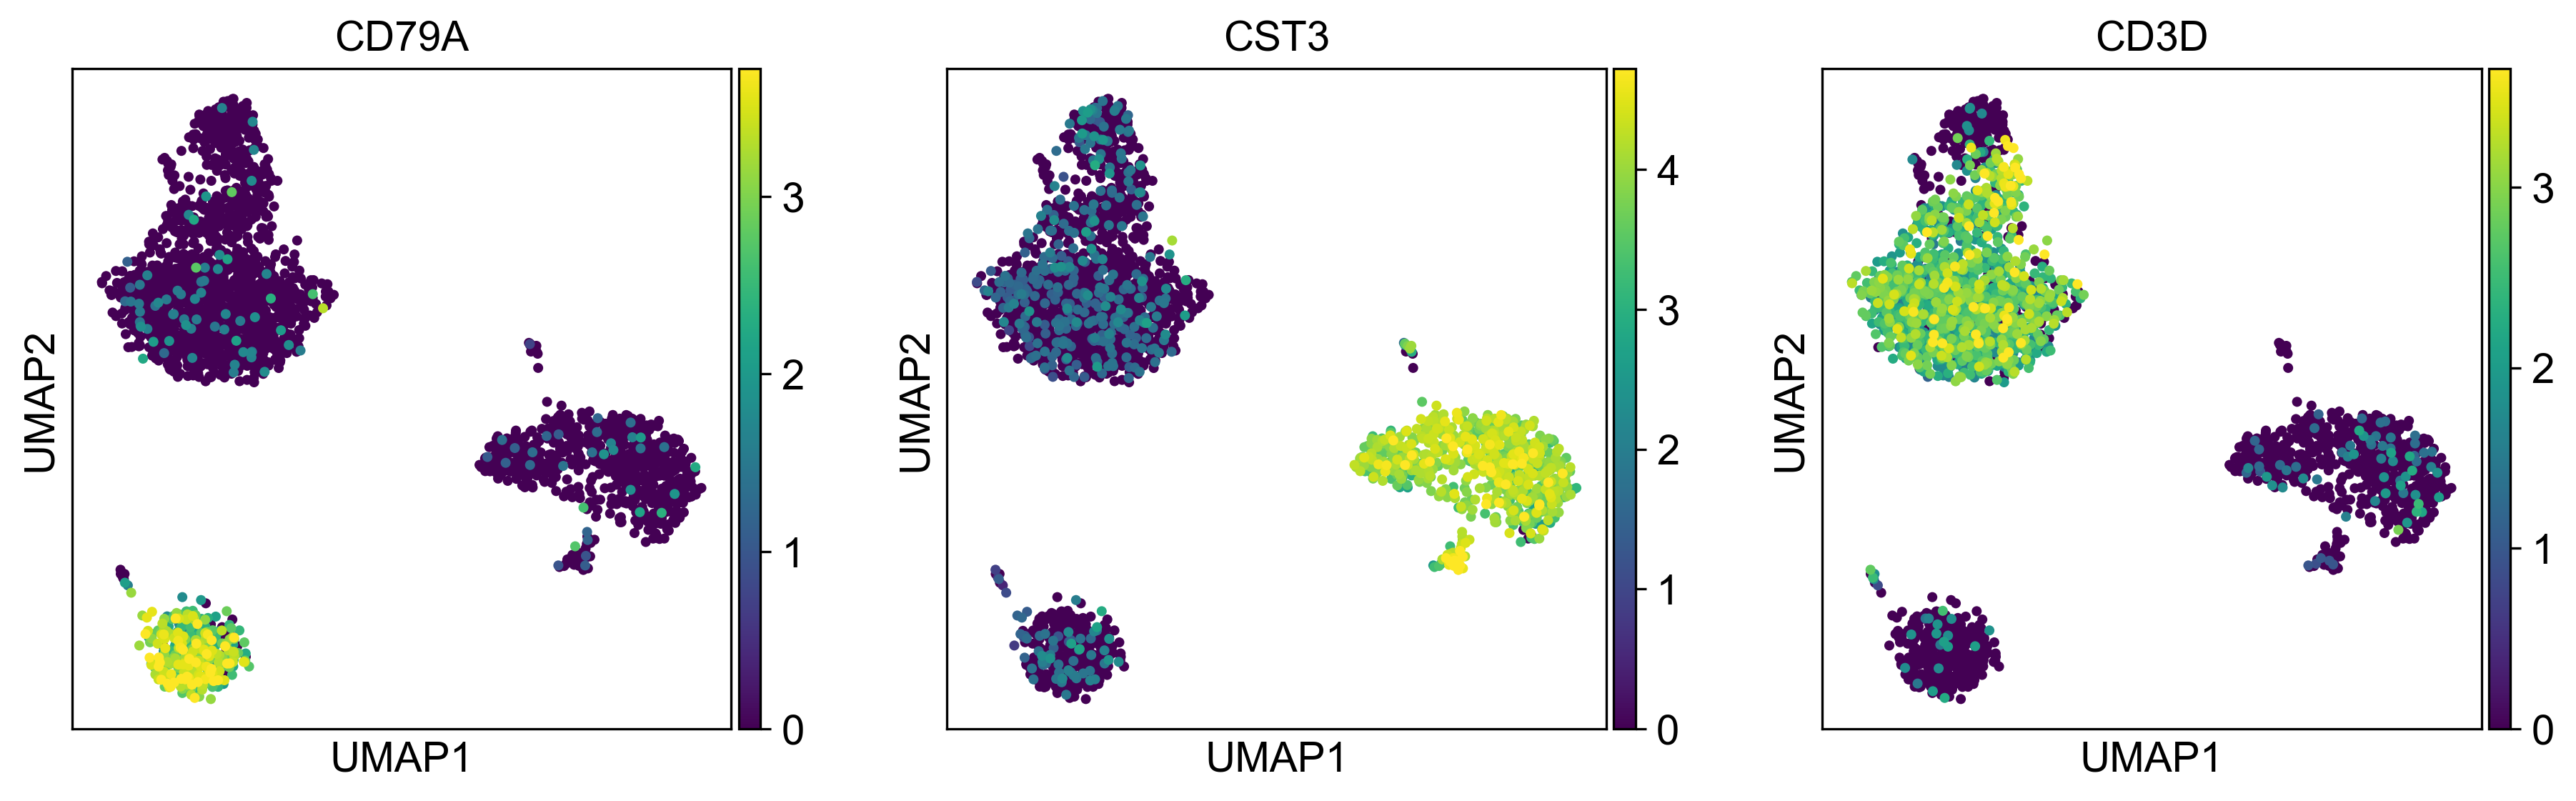

In [9]:
# 7. Visualization

# Plot the cells in 2D space, colored by their cluster assignment
sc.pl.umap(adata, color='leiden', title='Leiden Clustering of PBMC3k', legend_loc='on data')

# Plot the expression of a few specific biological marker genes
# CD79A = B cells, CST3 = Monocytes, CD3D = T cells
marker_genes = ['CD79A', 'CST3', 'CD3D']
sc.pl.umap(adata, color=marker_genes, cmap='viridis', vmax='p99')